In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from helper import Model0, DeepfakeDataset

SEED = 38

torch.manual_seed(SEED)

In [2]:
print("Test Dataset")
test_dataset = DeepfakeDataset("preprocessed/test", mode="test")
sample = test_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

Test Dataset
torch.Size([10, 3, 224, 224])
torch.Size([10, 1, 224, 224])
tensor(1.)


In [3]:
test_loader   = DataLoader(test_dataset, batch_size=8, shuffle=False)

model = Model0()
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [4]:
def test(model = model, loader = test_loader):
    model.eval()

    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader)

    with torch.no_grad():
        for batch in pbar:
            spatial = batch["spatial"]
            frequency = batch["frequency"]
            labels = batch["label"].unsqueeze(1)

            outputs = model(spatial, frequency)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

preds, labels = test()

acc = accuracy_score(labels, preds)
prec = precision_score(labels, preds)
rec = recall_score(labels, preds)
f1 = f1_score(labels, preds)

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1: {f1}")

100%|██████████| 60/60 [02:02<00:00,  2.04s/it]

Accuracy: 0.8875
Precision: 0.842741935483871
Recall: 0.9330357142857143
F1: 0.885593220338983


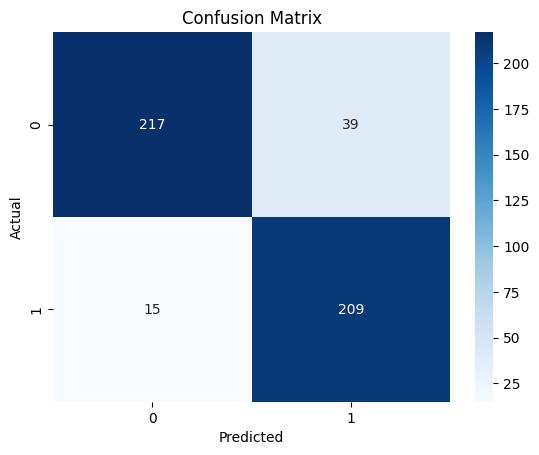

In [5]:
cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()